# Classification d'images à l'aide d'algorithmes de Deep Learning

Projet n&#8239;$^\text{o}$ 6 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 23/03/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

## Prérequis : installer les pilotes GPU, etc.

1. Installer ou mettre à jour le pilote pour la GPU. Par ici pour les GPU Nvidia : https://www.nvidia.com/en-us/drivers/ (spécifier le bon modèle dans le formulaire)

2. Installer le dernier CUDA toolkit (v13.2) de chez Nvidia : 

   - soit de la façon [`runfile (local)`][2] :

     ```bash
     # télécharger l'archive (taille approximative : 4,1 Go)
     wget https://developer.download.nvidia.com/compute/cuda/13.2.0/local_installers/cuda_13.2.0_595.45.04_linux.run

     # exécuter l'archive
     sudo sh cuda_13.2.0_595.45.04_linux.run
     ```

   - soit de la façon [`deb (network)`][3] :

     ```bash
     wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/cuda-keyring_1.1-1_all.deb
     
     sudo dpkg -i cuda-keyring_1.1-1_all.deb
     
     sudo apt update
     
     sudo apt -y install cuda-toolkit-13-2
     ```

3. Ajouter les chemins suivants aux variables d'environnement PATH et LD_LIBRARY_PATH :

     ```bash
     echo 'export PATH=/usr/local/cuda/bin:$PATH' >> ~/.bashrc
     echo 'export LD_LIBRARY_PATH=/usr/local/cuda/lib64:/usr/lib/x86_64-linux-gnu:$LD_LIBRARY_PATH' >> ~/.bashrc

     # Enfin, recharger .bashrc
     source ~/.bashrc
     ```

4. Installer le backend pour Keras (PyTorch, TensorFlow ou JAX) :

   - Pour PyTorch : Suivre [les instructions de la doc PyTorch][1] : Installer le backend `torch` and `torchvision` compatibles CUDA `>=13.0` pour les GPU Nvidia (ou ROCm `>=7.2` pour les GPU AMD).

   - Si besoin, spécifier dans `pyproject.toml` des bornes plus strictes à la version de Python : par exemple, non pas `>=3.12` mais `>=3.12,<3.14`.

5. Installer Keras : Suivre [les instructions de la doc Keras][4]

[1]: https://pytorch.org/get-started/locally/
[2]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=runfile_local
[3]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=deb_network
[4]: https://keras.io/getting_started/

# Notebook de création et d’entraînement du modèle personnel

## Imports et fonctions

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch" # valoriser cette variable d'environnement avant d'importer keras
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
from functions_model_from_scratch import (
    MyKerasSequence,
    plot_accuracy_and_loss_values,
)
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import keras
from keras import layers
from keras.preprocessing import image_dataset_from_directory

from collections import Counter
from lxml import etree
from pathlib import Path
from PIL import Image
from pprint import pprint
from sklearn.model_selection import train_test_split
import cv2
import datetime as dt
import joblib
import itertools as it
import matplotlib.pyplot as plt
import numpy as np
import pytz
import seaborn as sns
sns.set()

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

LOGGER_FORMAT = '%(asctime)s [%(levelname)s] %(message)s'
logging.Formatter.converter = lambda *_: dt.datetime.now(pytz.timezone('Europe/Paris')).timetuple()
logging.basicConfig(level=logging.INFO, format=LOGGER_FORMAT, force=True)
logr = logging.getLogger(__name__)
logr.setLevel(logging.DEBUG)
# log_file_handler = logging.FileHandler(f"log/{dt.datetime.isoformat(dt.datetime.now(pytz.timezone('Europe/Paris'))).split('.')[0]}.log")
# log_file_handler.setLevel(logging.DEBUG)
# log_cons_handler = logging.StreamHandler()
# log_cons_handler.setLevel(logging.DEBUG)
# log_file_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# log_cons_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# logr.addHandler(log_file_handler)
# logr.addHandler(log_cons_handler)


## Étapes préliminaires de test de l'installation

### Tester l'installation de CUDA toolkit et de PyTorch

In [2]:
logr.debug(f"PyTorch version: {torch.__version__}")
logr.debug(f"Is CUDA available: {torch.cuda.is_available()}")
logr.debug(f"CUDA device count: {torch.cuda.device_count()}")
logr.debug(f"Current device: {torch.cuda.current_device()}")
logr.debug(f"Device name: {torch.cuda.get_device_name(0)}")

2026-04-24 16:20:57,084 [DEBUG] PyTorch version: 2.11.0+cu130
2026-04-24 16:20:57,100 [DEBUG] Is CUDA available: True
2026-04-24 16:20:57,119 [DEBUG] CUDA device count: 1
2026-04-24 16:20:57,121 [DEBUG] Current device: 0
2026-04-24 16:20:57,121 [DEBUG] Device name: NVIDIA GeForce RTX 2070 with Max-Q Design


## Entraînement du modèle de prédiction *from scratch*

Recenser tous les répertoires contenant les images et les annotations :

In [3]:
img_file_paths = tuple(Path('images/').glob('*/'))
annot_file_paths = tuple(Path('annotations/').glob('*/'))

img_file_paths[0]

PosixPath('images/n02105251-briard')

Les répertoires contenant les images, triés en fonction du nombre d'images :

In [4]:
bag_of_file_counts = {
    dir_path: sum(1 for f in dir_path.iterdir() if f.is_file())
    for dir_path in img_file_paths
}
bag_of_file_counts_sorted_desc = dict(sorted(bag_of_file_counts.items(), reverse=True, key=lambda item: item[1]))
logr.info(f"Les répertoires contenant le plus d'images : {dict(list(bag_of_file_counts_sorted_desc.items())[:5])}")
display(dict(list(bag_of_file_counts_sorted_desc.items())[:5]))
logr.info(f"Les répertoires contenant le moins d'images : {dict(list(bag_of_file_counts_sorted_desc.items())[-5:])}")
display(dict(list(bag_of_file_counts_sorted_desc.items())[-5:]))

2026-04-24 16:20:57,344 [INFO] Les répertoires contenant le plus d'images : {PosixPath('images/n02085936-Maltese_dog'): 252, PosixPath('images/n02088094-Afghan_hound'): 239, PosixPath('images/n02092002-Scottish_deerhound'): 232, PosixPath('images/n02112018-Pomeranian'): 219, PosixPath('images/n02090721-Irish_wolfhound'): 218}


{PosixPath('images/n02085936-Maltese_dog'): 252,
 PosixPath('images/n02088094-Afghan_hound'): 239,
 PosixPath('images/n02092002-Scottish_deerhound'): 232,
 PosixPath('images/n02112018-Pomeranian'): 219,
 PosixPath('images/n02090721-Irish_wolfhound'): 218}

2026-04-24 16:20:57,346 [INFO] Les répertoires contenant le moins d'images : {PosixPath('images/n02115913-dhole'): 150, PosixPath('images/n02106166-Border_collie'): 150, PosixPath('images/n02101556-clumber'): 150, PosixPath('images/n02086079-Pekinese'): 149, PosixPath('images/n02090379-redbone'): 148}


{PosixPath('images/n02115913-dhole'): 150,
 PosixPath('images/n02106166-Border_collie'): 150,
 PosixPath('images/n02101556-clumber'): 150,
 PosixPath('images/n02086079-Pekinese'): 149,
 PosixPath('images/n02090379-redbone'): 148}

### Expérience 1 : Premier entraînement à 3 classes, d'abord sans *data augmentation*, ensuite avec

Nous allons donc sélectionner trois races selon le nombre d'images mises à notre disposition :

- Deux races contenant le plus d'images : **`Maltese_dog`** (252 images) et **`Afghan_hound`** (239 images).
- Une race contenant le moins d'images : **`redbone`** (148 images).

Split train - val - test :

In [5]:
input_img_paths = tuple(list(bag_of_file_counts_sorted_desc.keys())[i] for i in [-1, 0, 1])
logr.info(f"Les classes retenues : {input_img_paths}")
input_img_paths = tuple(path.glob('*.jpg') for path in input_img_paths)
input_img_paths = tuple(it.chain.from_iterable(input_img_paths))
logr.info(f"Résultat : un tuple de {len(input_img_paths)} images pour les 3 classes de races.")
breed_labels = tuple(str(path).split('/')[1] for path in input_img_paths)
logr.info(f"Distribution des classes : {dict(Counter(breed_labels))}")
display(dict(Counter(breed_labels)))
train_frac = 0.8
input_paths_train, input_paths_val_test, labels_train, labels_val_test = train_test_split(
    input_img_paths, breed_labels, train_size=train_frac,
    random_state=42, shuffle=True, stratify=breed_labels,
)
val_test_frac = 0.5
input_paths_val, input_paths_test, labels_val, labels_test = train_test_split(
    input_paths_val_test, labels_val_test, train_size=val_test_frac,
    random_state=42, shuffle=True, stratify=labels_val_test
)
del input_paths_val_test, labels_val_test
logr.info(f"Train size ({train_frac}): {len(input_paths_train)}")
logr.info(f"Val size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_val)}")
logr.info(f"Test size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_test)}")

2026-04-24 16:20:57,360 [INFO] Les classes retenues : (PosixPath('images/n02090379-redbone'), PosixPath('images/n02085936-Maltese_dog'), PosixPath('images/n02088094-Afghan_hound'))
2026-04-24 16:20:57,366 [INFO] Résultat : un tuple de 639 images pour les 3 classes de races.
2026-04-24 16:20:57,367 [INFO] Distribution des classes : {'n02090379-redbone': 148, 'n02085936-Maltese_dog': 252, 'n02088094-Afghan_hound': 239}


{'n02090379-redbone': 148,
 'n02085936-Maltese_dog': 252,
 'n02088094-Afghan_hound': 239}

2026-04-24 16:20:57,373 [INFO] Train size (0.8): 511
2026-04-24 16:20:57,373 [INFO] Val size (0.1): 64
2026-04-24 16:20:57,374 [INFO] Test size (0.1): 64


In [6]:
DEFAULT_TARGET_IMG_SIZE = (224, 224)
train_seq = MyKerasSequence(input_paths_train, labels_train, batch_size=32, target_size=DEFAULT_TARGET_IMG_SIZE)
val_seq = MyKerasSequence(input_paths_val, labels_val, batch_size=32, target_size=DEFAULT_TARGET_IMG_SIZE)
test_seq = MyKerasSequence(input_paths_test, labels_test, batch_size=32, target_size=DEFAULT_TARGET_IMG_SIZE)

#### a) Entraînement à 3 classes sans *data augmentation*

##### a) 1. Expérience 1 : La *baseline*

Construire le modèle :

In [7]:
IMG_SIZE   = 224
BATCH_SIZE = 64
EPOCHS     = 30
LR         = 1e-3
NUM_CLASSES = 120

data_augm = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomCrop(IMG_SIZE, IMG_SIZE),
    # layers.RandomRotation(0.1),   # ← décommenter selon besoin
    # layers.RandomZoom(0.1),
], name='data_augmentation')

def build_model(*, n_classes: int, include_data_augm: bool = True):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augm(inputs) if include_data_augm else inputs
    x = layers.Rescaling(1./255)(x)

    # Bloc 1 ─ CHANGER : filtres, taille kernel, ajouter BatchNorm
    x = layers.Conv2D(32, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    # Bloc 2 ─ CHANGER : ajouter d'autres blocs conv ici
    x = layers.Conv2D(64, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    # x = layers.Dropout(0.5)(x)   # ← décommenter pour régulariser

    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs)

model = build_model(n_classes=3, include_data_augm=False)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

Entraînement et validation :

2026-04-24 16:20:57,713 [INFO] Entraînement du modèle 'CNN_3_classes'...


Epoch 1/10


W0000 00:00:1777040459.515513 1200002 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 271ms/step - accuracy: 0.3718 - loss: 1.0898 - val_accuracy: 0.3906 - val_loss: 1.0784
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 267ms/step - accuracy: 0.4364 - loss: 1.0664 - val_accuracy: 0.5625 - val_loss: 1.0377
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - accuracy: 0.5538 - loss: 0.9926 - val_accuracy: 0.4844 - val_loss: 0.9378
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - accuracy: 0.5479 - loss: 0.9105 - val_accuracy: 0.5156 - val_loss: 0.8904
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.5753 - loss: 0.8699 - val_accuracy: 0.5781 - val_loss: 0.8535
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.5969 - loss: 0.8327 - val_accuracy: 0.5781 - val_loss: 0.8842
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step - accuracy: 0.6145 - loss: 0.8081 - val_accuracy: 0.5000 - val_loss: 0.8727
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 268ms/step - accuracy: 0.6732 - loss: 0.7704 - val_accuracy: 0.5312 - val_

2026-04-24 16:21:41,671 [INFO] Entraînement du modèle 'CNN_3_classes' terminé
2026-04-24 16:21:41,672 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_model.keras'
2026-04-24 16:21:44,567 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_history.joblib'


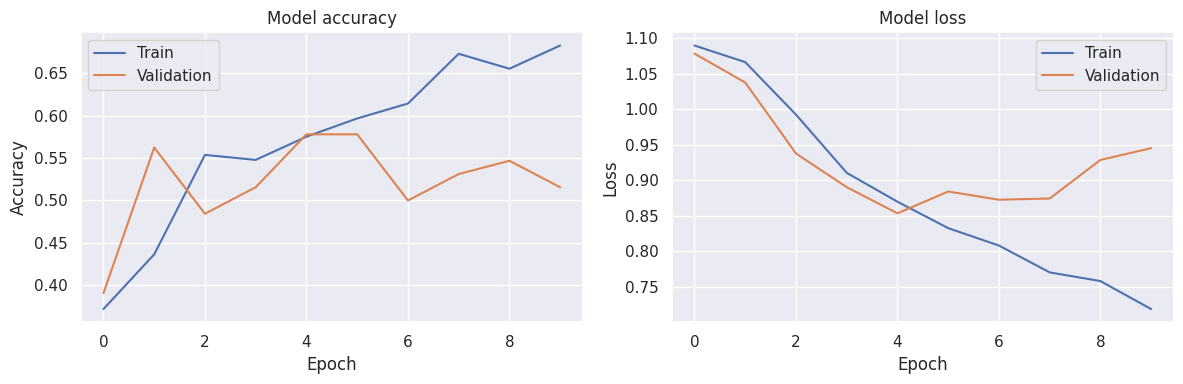

2026-04-24 16:21:50,478 [INFO] Final training accuracy: 0.6830
2026-04-24 16:21:50,480 [INFO] Final validation accuracy: 0.5156
2026-04-24 16:21:50,481 [INFO] Final training loss: 0.7187
2026-04-24 16:21:50,481 [INFO] Final validation loss: 0.9453


In [8]:
experiment_name = 'CNN_3_classes'
model_fname = f'models/{experiment_name}_model.keras'
history_fname = f'models/{experiment_name}_history.joblib'
if os.path.exists(model_fname) and os.path.exists(history_fname):
    logr.info(f"Désérialiser l'objet sauvegardé {model_fname!r}")
    model = keras.saving.load_model(model_fname)
    logr.info(f"Désérialiser l'objet sauvegardé {history_fname!r}")
    history = joblib.load(history_fname)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir="log/dogs_exp1")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=10, callbacks=callbacks)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {model_fname!r}")
    keras.saving.save_model(model, model_fname, overwrite=True)
    logr.info(f"Sauvegarder l'objet {history_fname!r}")
    joblib.dump(history, history_fname)
# Plot training & validation accuracy values
plot_accuracy_and_loss_values(history)
# Print final metrics
logr.info(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Final training loss: {history.history['loss'][-1]:.4f}")
logr.info(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

In [9]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")

2026-04-24 16:21:50,488 [INFO] Évaluation sur les données de test :


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.5312 - loss: 0.8732


2026-04-24 16:21:50,859 [INFO] loss, accuracy = [0.8731764554977417, 0.53125]


##### a) 2. Expérience 2 : À la recherche de la meilleure configuration

#### b) Entraînement à 3 classes avec *data augmentation*

Construire le modèle :

In [10]:
...

Ellipsis

Entraînement :

In [11]:
...

Ellipsis

Évaluation :

In [12]:
...

Ellipsis